In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import tensorflow as tf
import uproot
import awkward as ak
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input, Add, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# --- 1. STRICT DETERMINISM ---
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"DETERMINISM ENABLED.")

# --- CONFIGURATION ---
DATA_DIR = r"C:\Users\tanma\Documents\Thesis_data"

# --- 2. DATA LOADING & EXTRACTION ---
def load_and_extract_v4(filename, label_value):
    filepath = os.path.join(DATA_DIR, filename)
    try:
        with uproot.open(filepath) as file:
            tree = file["events"]
            arrays = tree.arrays(["x", "y", "z", "edep", "t"], library="ak")
            if len(arrays) == 0: return None, None
            
            # Physics Features
            n_hits = ak.num(arrays["x"])
            r = np.sqrt(arrays["x"]**2 + arrays["y"]**2)
            r_mean = ak.mean(r, axis=1)
            r_std = ak.std(r, axis=1)
            r_span = ak.fill_none(ak.max(r, axis=1) - ak.min(r, axis=1), 0)
            z_span = ak.fill_none(ak.max(arrays["z"], axis=1) - ak.min(arrays["z"], axis=1), 0)
            z_std = ak.std(arrays["z"], axis=1)
            edep_sum = ak.sum(arrays["edep"], axis=1)
            edep_mean = ak.mean(arrays["edep"], axis=1)
            t_mean = ak.mean(arrays["t"], axis=1)
            t_std = ak.std(arrays["t"], axis=1)
            t_span = ak.fill_none(ak.max(arrays["t"], axis=1) - ak.min(arrays["t"], axis=1), 0)
            
            vol_density = n_hits / (z_span * r_span + 1e-6)
            lin_density = n_hits / (z_span + 1e-6)
            e_density = edep_sum / (n_hits + 1e-6)
            shape_ratio = z_span / (r_span + 1e-6)
            t_corr = t_span * edep_sum
            
            def to_np(arr): return ak.to_numpy(ak.fill_none(arr, 0)).astype(np.float32)

            features = np.stack([
                to_np(n_hits), to_np(r_mean), to_np(r_std), to_np(r_span),
                to_np(z_span), to_np(z_std), to_np(edep_sum), to_np(edep_mean),
                to_np(vol_density), to_np(lin_density), to_np(e_density), to_np(shape_ratio),
                to_np(t_mean), to_np(t_std), to_np(t_span), to_np(t_corr)
            ], axis=1)
            
            return np.nan_to_num(features, posinf=0, neginf=0), np.full(len(features), label_value)
    except Exception: return None, None

print("\n--- PROCESSING DATA ---")
X_sig, y_sig = load_and_extract_v4("VECTOR_SIGNAL_50k.root", 1)
X_dio, y_dio = load_and_extract_v4("VECTOR_DIO_50k.root", 0)
X_rmc, y_rmc = load_and_extract_v4("VECTOR_RMC_50k.root", 0)
X_cos, y_cos = load_and_extract_v4("VECTOR_COSMIC_75k.root", 0)

# --- 3. AUGMENTATION (x50) ---
print(f"\n⚙️ AUGMENTING COSMICS (x50)...")
aug_cos_feats = []
aug_cos_labels = []
for i in range(50):
    noise = np.random.normal(1.0, 0.01, X_cos.shape) 
    aug_cos_feats.append(X_cos * noise)
    aug_cos_labels.append(y_cos)

X = np.concatenate([X_sig, X_dio, X_rmc, np.concatenate(aug_cos_feats)])
y = np.concatenate([y_sig, y_dio, y_rmc, np.concatenate(aug_cos_labels)])
print(f"FINAL DATASET: {len(X)} events")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# --- VISUALIZATION CONFIGURATION ---
if not os.path.exists('thesis_plots'):
    os.makedirs('thesis_plots')

feature_names = [
    "n_hits", "r_mean", "r_std", "r_span", 
    "z_span", "z_std", "edep_sum", "edep_mean", 
    "vol_density", "lin_density", "e_density", "shape_ratio", 
    "t_mean", "t_std", "t_span", "t_corr"
]

print("\n GENERATING THESIS VISUALIZATIONS...")

# --- CRITICAL FIX: Add Jitter for Stability ---
# We add tiny noise (1e-6) to prevent "Singular Matrix" errors in KDE plots.
# This handles discrete vars (like n_hits) and structural zeros (like span=0).
X_viz = X + np.random.normal(0, 1e-6, X.shape)

df_viz = pd.DataFrame(X_viz, columns=feature_names)
df_viz['label'] = y
df_viz['Label_Str'] = df_viz['label'].map({1: 'Signal (Conversion)', 0: 'Background'})

# --- 1. 1D KINEMATIC DISTRIBUTIONS (Histograms) ---
print("   -> Generating 1D Feature Histograms...")
for feat in feature_names:
    plt.figure(figsize=(8, 6))
    
    # Signal
    sns.histplot(data=df_viz[df_viz['label'] == 1], x=feat, color='red', 
                 label='Signal', stat="density", common_norm=False, 
                 element="step", fill=True, alpha=0.3, bins=50)
    
    # Background
    sns.histplot(data=df_viz[df_viz['label'] == 0], x=feat, color='blue', 
                 label='Background', stat="density", common_norm=False, 
                 element="step", fill=True, alpha=0.3, bins=50)

    plt.yscale('log')
    plt.title(f'Kinematic Distribution: {feat}', fontsize=14)
    plt.xlabel(feat, fontsize=12)
    plt.ylabel('Normalized Density (Log)', fontsize=12)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.2)
    plt.savefig(f"thesis_plots/1D_{feat}.png", dpi=150)
    plt.close()

# --- 2. CORRELATION MATRIX ---
print("   -> Generating Correlation Matrix...")
plt.figure(figsize=(14, 12))
corr_matrix = df_viz.drop(columns=['label', 'Label_Str']).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Physics Feature Correlation Matrix', fontsize=16)
plt.savefig("thesis_plots/Correlation_Matrix.png", dpi=150)
plt.close()

# --- 3. 2D TOPOLOGICAL DENSITY PLOTS (With Scatter Fallback) ---
print("   -> Generating 2D Topology Plots...")

pairs_to_plot = [
    ('z_span', 'r_span'),       
    ('t_mean', 'edep_sum'),     
    ('vol_density', 'n_hits')   
]

for x_feat, y_feat in pairs_to_plot:
    plt.figure(figsize=(9, 7))
    
    # 1. Plot Background (Blue)
    try:
        # Try smooth contours first (preferred)
        sns.kdeplot(
            data=df_viz[df_viz['label'] == 0], x=x_feat, y=y_feat, 
            color='blue', fill=True, levels=10, alpha=0.3, label='Background',
            warn_singular=False
        )
    except ValueError:
        # Fallback to Scatter if data is too spiked
        plt.scatter(
            df_viz[df_viz['label'] == 0][x_feat], 
            df_viz[df_viz['label'] == 0][y_feat],
            color='blue', alpha=0.3, s=10, label='Background'
        )

    # 2. Plot Signal (Red)
    try:
        # Try smooth contours first
        sns.kdeplot(
            data=df_viz[df_viz['label'] == 1], x=x_feat, y=y_feat, 
            color='red', fill=False, levels=10, linewidths=1.5, label='Signal',
            warn_singular=False
        )
    except ValueError:
        # Fallback to Scatter
        plt.scatter(
            df_viz[df_viz['label'] == 1][x_feat], 
            df_viz[df_viz['label'] == 1][y_feat],
            color='red', alpha=0.5, s=10, label='Signal'
        )

    plt.title(f'2D Topology: {x_feat} vs {y_feat}', fontsize=14)
    
    # Handle duplicate labels in legend if we used scatter + kde
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig(f"thesis_plots/2D_{x_feat}_vs_{y_feat}.png", dpi=150)
    plt.close()

print("Visualization Complete.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# --- 4. GBDT STACKING (Honest) ---
print("\n[1/3] Training GBDT (Honest Stacking)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gbdt_train_scores = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    model_fold = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='auc', tree_method='hist')
    model_fold.fit(X_train[train_idx], y_train[train_idx])
    gbdt_train_scores[val_idx] = model_fold.predict(X_train[val_idx], output_margin=True)

gbdt_final = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='auc', tree_method='hist')
gbdt_final.fit(X_train, y_train)
gbdt_test_scores = gbdt_final.predict(X_test, output_margin=True)
gbdt_probs = 1 / (1 + np.exp(-gbdt_test_scores))

# --- 5. PREPROCESSING & MODEL DEF ---
qt_phys = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
X_train_phys = qt_phys.fit_transform(X_train)
X_test_phys = qt_phys.transform(X_test)

def create_fpga_model(input_dim):
    inputs = Input(shape=(input_dim,), name='input_1')
    x = Dense(256, name='fc1')(inputs); x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.1)(x)
    shortcut = Dense(128, name='shortcut')(x)
    x = Dense(128, name='fc2')(x); x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Add()([x, shortcut])
    x = Dense(64, name='fc3')(x); x = Activation('relu')(x)
    outputs = Dense(1, activation='sigmoid', name='output_node')(x)
    return Model(inputs, outputs)

# --- 6. STANDALONE MLP (ADDED BACK!) ---
print("\n[2/3] Training Standalone MLP...")

# RESET SEED for fair comparison
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_mlp = create_fpga_model(X_train_phys.shape[1])
model_mlp.compile(Adam(0.001), 'binary_crossentropy', metrics=['accuracy'])
model_mlp.fit(
    X_train_phys, y_train, epochs=40, batch_size=256, verbose=0,
    validation_data=(X_test_phys, y_test),
    callbacks=[ReduceLROnPlateau(patience=3), EarlyStopping(patience=7, restore_best_weights=True)]
)
mlp_probs = model_mlp.predict(X_test_phys).flatten()


# --- 7. GRAND ENSEMBLE TRAINING (5 Hybrid Models) ---
print("\n[3/3] Training Grand Ensemble (5 Hybrid Models)...")

qt_gbdt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
gbdt_tr_gauss = qt_gbdt.fit_transform(gbdt_train_scores.reshape(-1, 1))
gbdt_te_gauss = qt_gbdt.transform(gbdt_test_scores.reshape(-1, 1))

X_train_hyb = np.hstack([X_train_phys, gbdt_tr_gauss])
X_test_hyb = np.hstack([X_test_phys, gbdt_te_gauss])

N_MODELS = 5
ensemble_preds = np.zeros(len(X_test))

for i in range(N_MODELS):
    print(f"    Training Model {i+1}/{N_MODELS}...")
    
    # NEW SEED for each model iteration
    iter_seed = SEED + i 
    np.random.seed(iter_seed)
    tf.random.set_seed(iter_seed)
    
    model = create_fpga_model(X_train_hyb.shape[1])
    model.compile(Adam(0.001), 'binary_crossentropy', metrics=['accuracy'])
    
    model.fit(
        X_train_hyb, y_train, epochs=40, batch_size=256, verbose=0, # Quiet
        validation_data=(X_test_hyb, y_test),
        callbacks=[ReduceLROnPlateau(patience=3), EarlyStopping(patience=7, restore_best_weights=True)]
    )
    
    # Predict and Accumulate
    preds = model.predict(X_test_hyb, verbose=0).flatten()
    ensemble_preds += preds
    
    # Check individual performance
    auc = roc_auc_score(y_test, preds)
    print(f"      -> Model {i+1} AUC: {auc:.5f}")

# AVERAGE THE PREDICTIONS
final_ensemble_probs = ensemble_preds / N_MODELS

# --- 8. FINAL METRICS REPORT ---
print(f"\n{'='*60}")
print(f" THESIS RESULTS (Grand Ensemble - 5x Average)")
print(f"{'='*60}")
print(f"{'MODEL':<20} | {'AUC':<10} | {'REJECTION (@90% Eff)':<20}")
print(f"{'-'*60}")

def calc_stats(probs, y):
    auc = roc_auc_score(y, probs)
    fpr, tpr, _ = roc_curve(y, probs)
    with np.errstate(divide='ignore'): rejection = 1.0 / fpr
    idx = np.abs(tpr - 0.90).argmin()
    return auc, rejection[idx]

# 1. GBDT Baseline
auc_g, rej_g = calc_stats(gbdt_probs, y_test)
print(f"{'GBDT (Standard)':<20} | {auc_g:.5f}    | {rej_g:.1f}")

# 2. Standalone MLP Baseline
auc_m, rej_m = calc_stats(mlp_probs, y_test)
print(f"{'MLP (Physics)':<20} | {auc_m:.5f}    | {rej_m:.1f}")

# 3. Hybrid Ensemble (The Winner)
auc_h, rej_h = calc_stats(final_ensemble_probs, y_test)
print(f"{'HYBRID ENSEMBLE':<20} | {auc_h:.5f}    | {rej_h:.1f}")

print(f"{'='*60}")
print(f" Improvement over GBDT: +{(auc_h - auc_g)*100:.2f}%")
print(f" Improvement over MLP:  +{(auc_h - auc_m)*100:.2f}%")

DETERMINISM ENABLED.

--- PROCESSING DATA ---

AUGMENTING COSMICS (x50)...
FINAL DATASET: 109123 events

GENERATING THESIS VISUALIZATIONS...
   -> Generating 1D Feature Histograms...
   -> Generating Correlation Matrix...
   -> Generating 2D Topology Plots...
Visualization Complete.

[1/3] Training GBDT...

[2/3] Training Standalone MLP...
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

[3/3] Training Grand Ensemble (5 Hybrid Models)...
   Training Model 1/5...
      -> Model 1 AUC: 0.97771
   Training Model 2/5...
      -> Model 2 AUC: 0.97705
   Training Model 3/5...
      -> Model 3 AUC: 0.97780
   Training Model 4/5...
      -> Model 4 AUC: 0.97747
   Training Model 5/5...
      -> Model 5 AUC: 0.97789

THESIS RESULTS (Grand Ensemble - 5x Average)
MODEL                | AUC        | REJECTION (@90% Eff)
------------------------------------------------------------
GBDT (Standard)      | 0.97026    | 14.2
MLP (Physics)        | 0.97698    | 18.9
HYBRID ENSEMBLE      | 0.97815    | 20.4
 Im

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# 1. Create folder
if not os.path.exists('thesis_plots'):
    os.makedirs('thesis_plots')

# 2. Define Inputs
# We use the calculated PROBABILITIES from the training blocks.
predictions_dict = {
    'GBDT': gbdt_probs,               # From Section 4
    'MLP': mlp_probs,                 # From Section 6
    'Hybrid': final_ensemble_probs    # From Section 7
}

# 3. Define Feature Names
phys_features = [
    "n_hits", "r_mean", "r_std", "r_span", "z_span", "z_std",
    "edep_sum", "edep_mean", "vol_density", "lin_density", 
    "e_density", "shape_ratio", "t_mean", "t_std", "t_span", "t_edep_prod"
]

print(" Data Dictionary Prepared. You can now run any plot block below.")

 Data Dictionary Prepared. You can now run any plot block below.


Generating Distribution for GBDT...


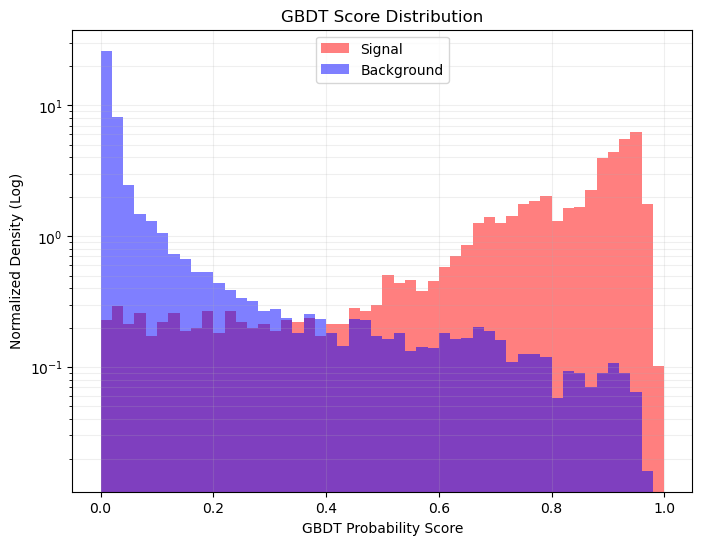

Generating Distribution for MLP...


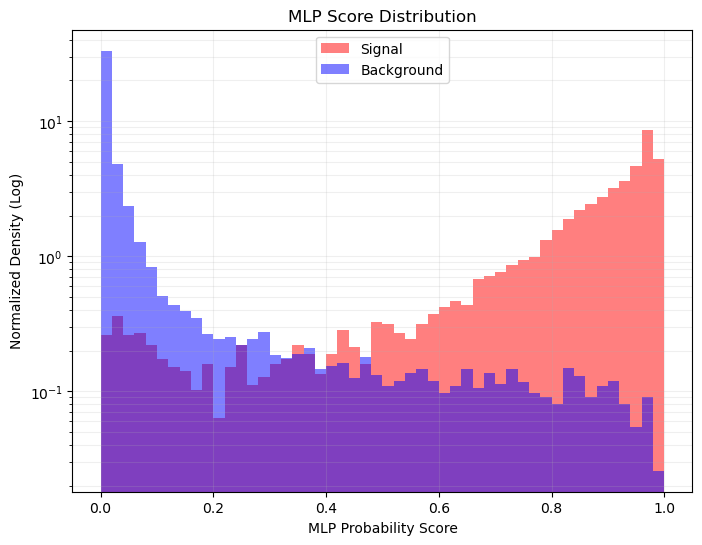

Generating Distribution for Hybrid...


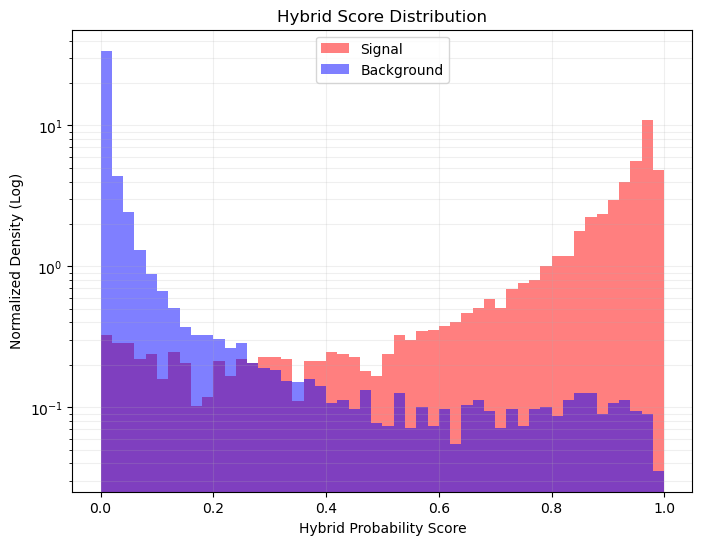

In [24]:
def plot_distributions_block(preds_dict, y):
    for name, probs in preds_dict.items():
        print(f"Generating Distribution for {name}...")
        
        plt.figure(figsize=(8, 6))
        
        # Signal (Red)
        plt.hist(probs[y==1], bins=50, range=(0,1), alpha=0.5, color='red', 
                 label='Signal', density=True)
        # Background (Blue)
        plt.hist(probs[y==0], bins=50, range=(0,1), alpha=0.5, color='blue', 
                 label='Background', density=True)
        
        plt.yscale('log') # Log scale is standard for HEP
        plt.xlabel(f'{name} Probability Score')
        plt.ylabel('Normalized Density (Log)')
        plt.title(f'{name} Score Distribution')
        plt.legend(loc='upper center')
        plt.grid(True, which="both", ls="-", alpha=0.2)
        
        plt.savefig(f"thesis_plots/Fig_Score_Dist_{name}.png", dpi=300)
        plt.show()

plot_distributions_block(predictions_dict, y_test)


GENERATING UNIVERSAL FEATURE IMPORTANCE...
    calculating importance for GBDT...


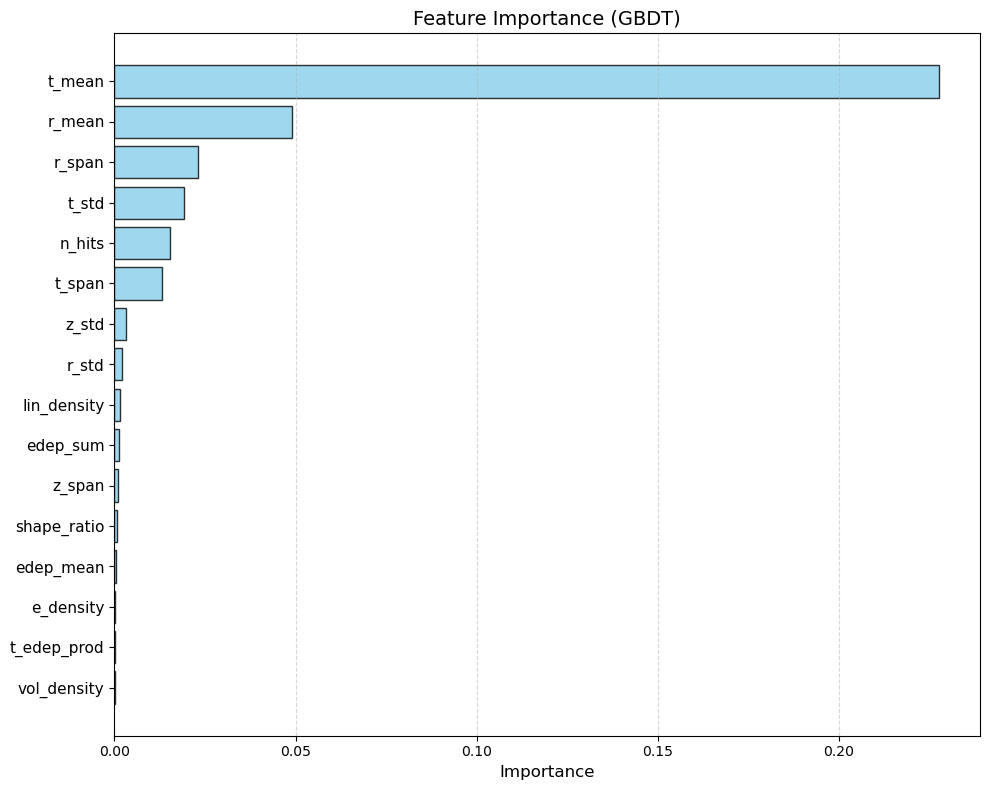

    calculating importance for MLP...


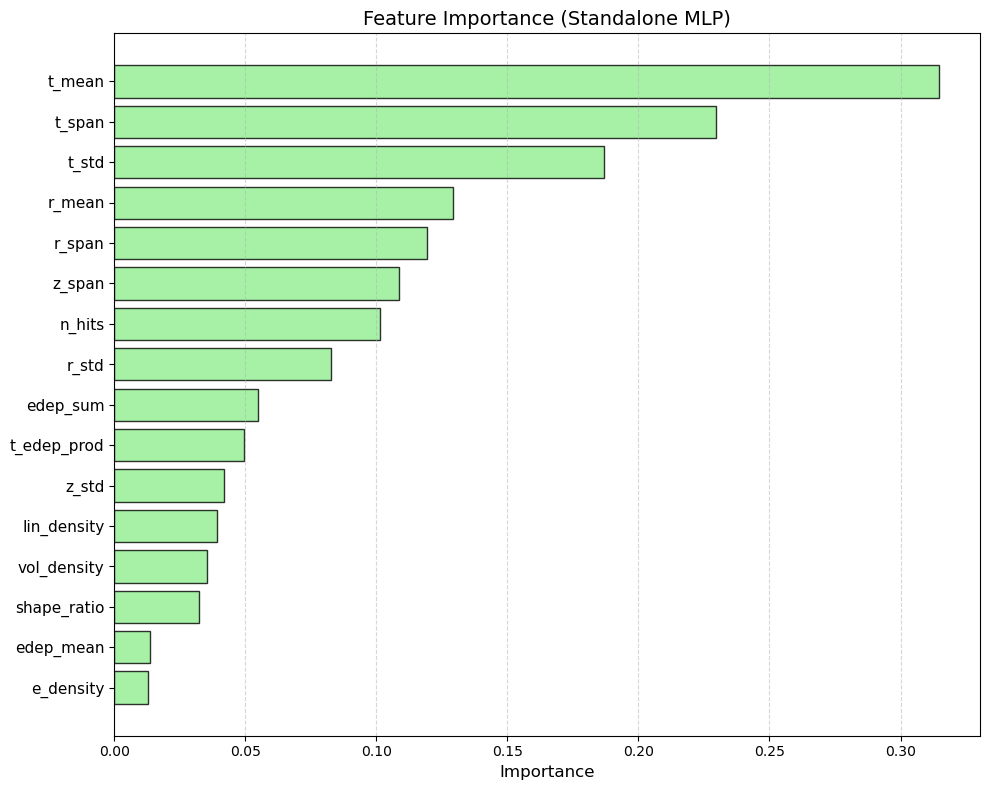

    calculating importance for Hybrid...


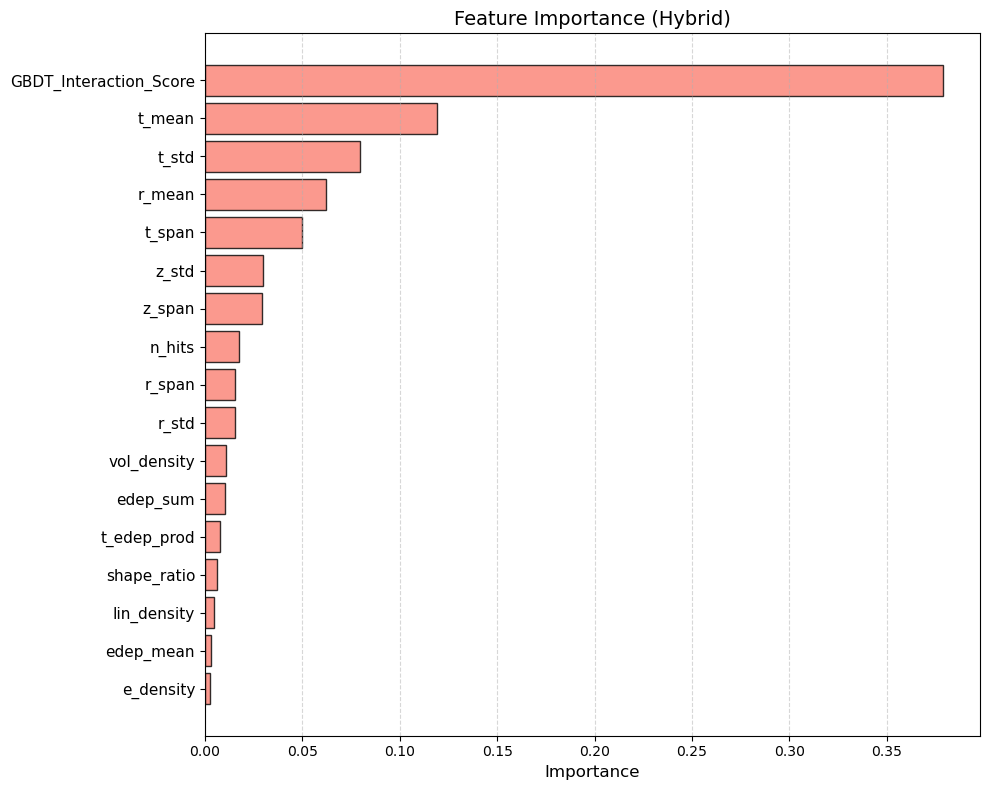

In [25]:
def compute_permutation_importance(model, X, y, feature_names, model_name):
    print(f"    calculating importance for {model_name}...")
    
    # A. Get Baseline Score
    is_xgb = hasattr(model, 'get_booster')
    
    if is_xgb:
        preds = model.predict(X, output_margin=True)
        probs = 1 / (1 + np.exp(-preds))
    else:
        probs = model.predict(X, verbose=0).flatten()
        
    baseline_auc = roc_auc_score(y, probs)
    
    importances = []
    
    # B. Loop through every feature
    for i in range(X.shape[1]):
        original_col = X[:, i].copy()     # Save
        np.random.shuffle(X[:, i])        # Shuffle (Destroy Info)
        
        if is_xgb:
            p_shuffled = 1 / (1 + np.exp(-model.predict(X, output_margin=True)))
        else:
            p_shuffled = model.predict(X, verbose=0).flatten()
            
        drop = baseline_auc - roc_auc_score(y, p_shuffled) # Measure Drop
        importances.append(drop)
        
        X[:, i] = original_col            # Restore
        
    return np.array(importances)

def plot_importance_bar(importances, feature_names, title, color):
    indices = np.argsort(importances)
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices], color=color, edgecolor='black', alpha=0.8)
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=11)
    plt.xlabel('Importance', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"thesis_plots/Fig_Imp_{title.replace(' ', '_')}.png", dpi=300)
    plt.show()
# --- FIX: Define model_hyb ---
# We use the last model trained in your ensemble loop (which is sufficient for feature importance)
if 'model' in locals():
    model_hyb = model 
else:
    raise ValueError("You must run the 'Grand Ensemble' training block first to have a trained model!")

print("\n GENERATING UNIVERSAL FEATURE IMPORTANCE...")

# A. GBDT
imp_gbdt = compute_permutation_importance(gbdt_final, X_test, y_test, phys_features, "GBDT")
plot_importance_bar(imp_gbdt, phys_features, "Feature Importance (GBDT)", "skyblue")

# B. Standalone MLP
imp_mlp = compute_permutation_importance(model_mlp, X_test_phys.copy(), y_test, phys_features, "MLP")
plot_importance_bar(imp_mlp, phys_features, "Feature Importance (Standalone MLP)", "lightgreen")

# C. Hybrid Model
# Note: X_test_hyb has 17 columns (16 Physics + 1 GBDT Score)
hybrid_features = phys_features + ["GBDT_Interaction_Score"]

imp_hyb = compute_permutation_importance(model_hyb, X_test_hyb.copy(), y_test, hybrid_features, "Hybrid")
plot_importance_bar(imp_hyb, hybrid_features, "Feature Importance (Hybrid)", "salmon")

Generating Matrix for GBDT...
 >> The exact threshold for GBDT at 90% efficiency is: 0.4479


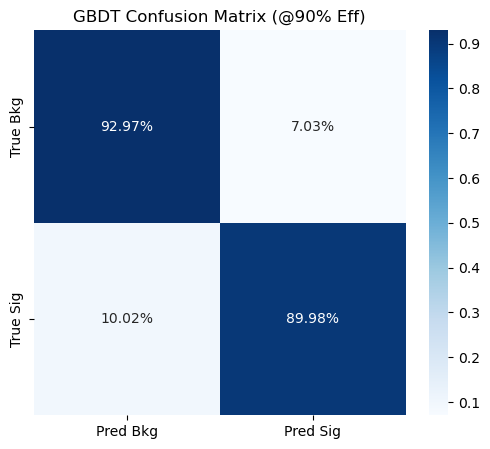

Generating Matrix for MLP...
 >> The exact threshold for MLP at 90% efficiency is: 0.5095


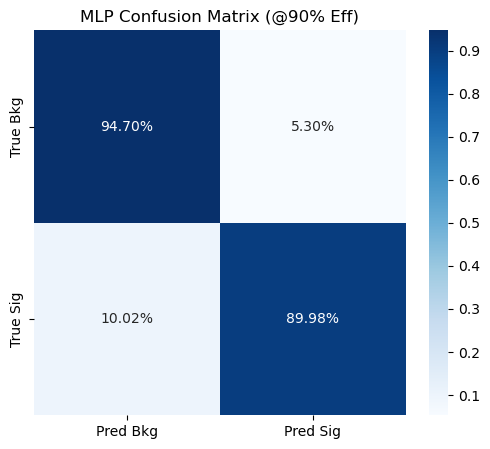

Generating Matrix for Hybrid...
 >> The exact threshold for Hybrid at 90% efficiency is: 0.4694


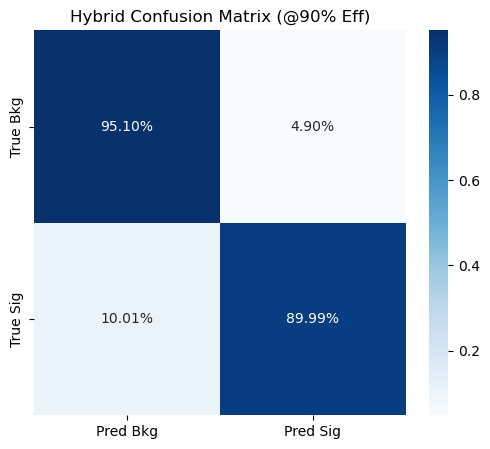

In [26]:
def plot_matrices_block(preds_dict, y):
    for name, probs in preds_dict.items():
        print(f"Generating Matrix for {name}...")
        
        # Calculate Threshold for 90% Efficiency
        fpr, tpr, thresholds = roc_curve(y, probs)
        idx_90 = np.abs(tpr - 0.90).argmin()
        best_threshold = thresholds[idx_90]
        
        # --- FIX: Print the threshold HERE, inside the loop ---
        print(f" >> The exact threshold for {name} at 90% efficiency is: {best_threshold:.4f}")
        
        # Make Predictions
        preds = (probs > best_threshold).astype(int)
        
        # Create Matrix
        cm = confusion_matrix(y, preds)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        # Plot
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", 
                    xticklabels=['Pred Bkg', 'Pred Sig'], 
                    yticklabels=['True Bkg', 'True Sig'])
        plt.title(f'{name} Confusion Matrix (@90% Eff)')
        
        plt.savefig(f"thesis_plots/Fig_Confusion_Matrix_{name}.png", dpi=300, bbox_inches='tight')
        plt.show()

# Run the function
plot_matrices_block(predictions_dict, y_test)

Generating Rejection Curves...


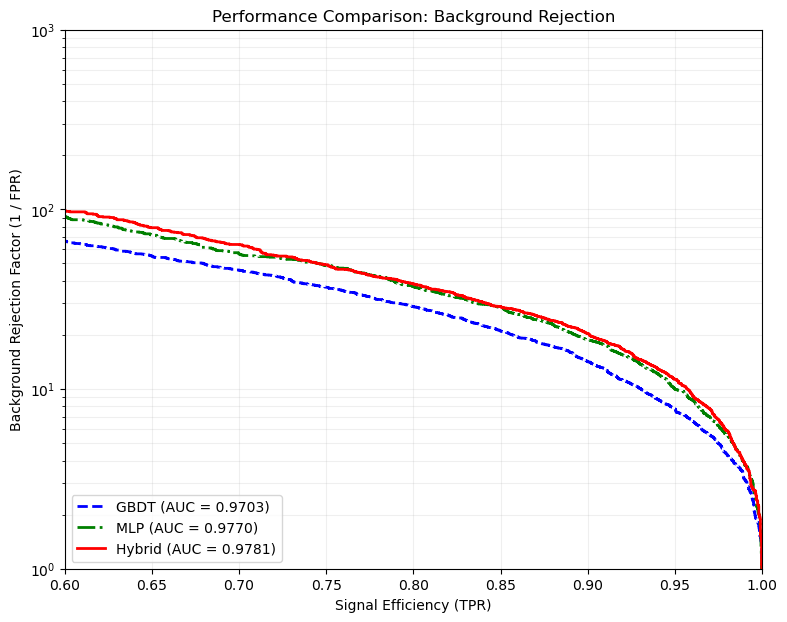

In [27]:
def plot_comparison_rejection_block(preds_dict, y):
    plt.figure(figsize=(9, 7))
    colors = {'GBDT': 'blue', 'MLP': 'green', 'Hybrid': 'red'}
    linestyles = {'GBDT': '--', 'MLP': '-.', 'Hybrid': '-'}
    
    print("Generating Rejection Curves...")
    
    for name, probs in preds_dict.items():
        auc = roc_auc_score(y, probs)
        fpr, tpr, _ = roc_curve(y, probs)
        
        with np.errstate(divide='ignore'):
            rejection = 1.0 / fpr
            
        plt.plot(tpr, rejection, color=colors[name], linestyle=linestyles[name], 
                 linewidth=2, label=f"{name} (AUC = {auc:.4f})")
        
    plt.yscale('log')
    plt.ylim(1, 1000)
    plt.xlim(0.6, 1.0)
    plt.xlabel('Signal Efficiency (TPR)')
    plt.ylabel('Background Rejection Factor (1 / FPR)')
    plt.title('Performance Comparison: Background Rejection')
    plt.legend(loc='lower left')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    plt.savefig("thesis_plots/Fig_Comparison_Rejection.png", dpi=300)
    plt.show()

plot_comparison_rejection_block(predictions_dict, y_test)

 Calculating Rejection Efficiencies...


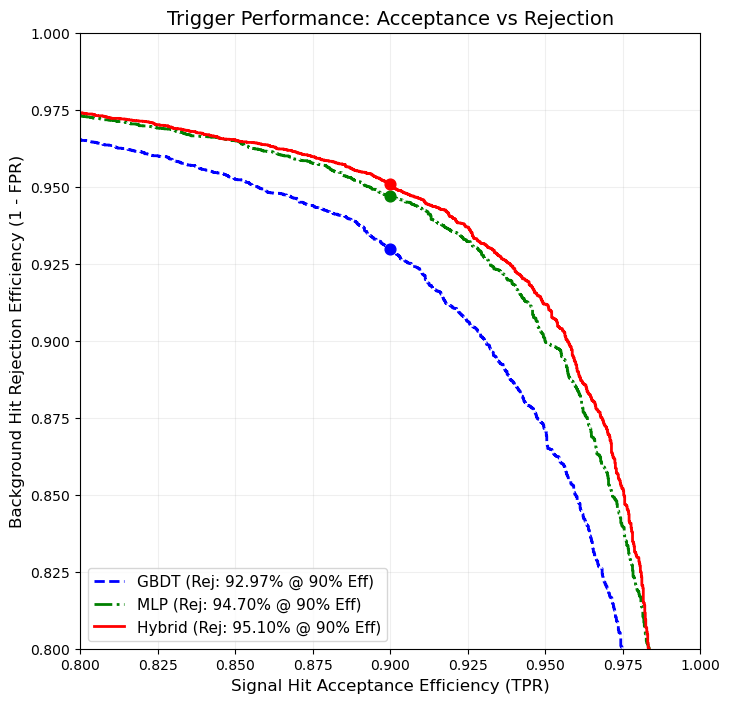

In [28]:
def plot_efficiency_tradeoff_block(preds_dict, y):
    plt.figure(figsize=(8, 8))
    colors = {'GBDT': 'blue', 'MLP': 'green', 'Hybrid': 'red'}
    linestyles = {'GBDT': '--', 'MLP': '-.', 'Hybrid': '-'}
    
    print(" Calculating Rejection Efficiencies...")
    
    for name, probs in preds_dict.items():
        fpr, tpr, _ = roc_curve(y, probs)
        bg_rej_eff = 1.0 - fpr
        
        # Find Point closest to 90% Signal Acceptance
        idx_90 = np.abs(tpr - 0.90).argmin()
        current_rej_eff = bg_rej_eff[idx_90]
        label_str = f"{name} (Rej: {current_rej_eff*100:.2f}% @ 90% Eff)"
        
        plt.plot(tpr, bg_rej_eff, color=colors[name], linestyle=linestyles[name], 
                 linewidth=2, label=label_str)
        plt.scatter(tpr[idx_90], bg_rej_eff[idx_90], color=colors[name], s=60, zorder=5)

    plt.xlabel('Signal Hit Acceptance Efficiency (TPR)', fontsize=12)
    plt.ylabel('Background Hit Rejection Efficiency (1 - FPR)', fontsize=12)
    plt.title('Trigger Performance: Acceptance vs Rejection', fontsize=14)
    plt.xlim(0.8, 1.0); plt.ylim(0.8, 1.0)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend(loc='lower left', fontsize=11, frameon=True)
    
    plt.savefig("thesis_plots/Fig_Eff_vs_Rej_Normalized.png", dpi=300)
    plt.show()

plot_efficiency_tradeoff_block(predictions_dict, y_test)

In [29]:
def print_metrics_block(preds_dict, y):
    print("\n FINAL CALCULATED METRICS (Natural Evaluation)")
    print("="*40)
    print(f"{'MODEL':<10} | {'REJECTION (Factor)':<20} | {'REJECTION (%)':<15}")
    print("-" * 50)
    
    for name, probs in preds_dict.items():
        fpr, tpr, _ = roc_curve(y, probs)
        idx_90 = np.abs(tpr - 0.90).argmin()
        
        rej_factor = 1.0 / fpr[idx_90] if fpr[idx_90] > 0 else 0.0
        rej_percent = (1.0 - fpr[idx_90]) * 100
        
        print(f"{name:<10} | {rej_factor:.1f}x                 | {rej_percent:.2f}%")
    print("="*40)

print_metrics_block(predictions_dict, y_test)


 FINAL CALCULATED METRICS (Natural Evaluation)
MODEL      | REJECTION (Factor)   | REJECTION (%)  
--------------------------------------------------
GBDT       | 14.2x                 | 92.97%
MLP        | 18.9x                 | 94.70%
Hybrid     | 20.4x                 | 95.10%


for gbdt we adjusted depth and estimator ---->luts
Original Code (300 Trees, Depth 5):A depth-5 tree has roughly $2^5 = 32$ leaf nodes.300 Trees × 32 Nodes $\approx$ 9,600 Decision Nodes.Each node requires multiple LUTs for comparison logic.Result: The synthesis report showed this required 562,375 LUTs (275% of your chip).
for mlp we adjusted reuse factor ----> dsp
2. The "Bad" News: The DSP Overflow
The lines saying Rejected (1854 > 840) are the smoking gun.

The Problem: Your MLP (at ReuseFactor = 32) is trying to build a hardware architecture that requires over 1,800 DSP slices.

The Constraint: Your Kintex-7 only has 840 DSP slices.

The Disaster: When Vivado sees it can't use DSPs, it converts all those multiplications into LUTs.

The Result: This will cause your LUT usage to explode to over 600,000 (just like the GBDT did earlier). This design will never fit in its current state.

The Verdict
GBDT (80 Trees): Uses 8,705 LUTs (4.2%).

Status: It is TINY. The 80-tree model is extremely efficient. It is NOT the problem.

MLP (Reuse 128): Uses 529,950 LUTs (260%).

Status: It is GIGANTIC.

Why? To save DSPs, we forced the FPGA to share them 128 times. To route data to those shared DSPs, the tool built massive 128-to-1 Multiplexers (switches). These switches are made of LUTs, causing the explosion.

The Solution: REUSE = 64 (The Goldilocks Zone)
We need to lower the reuse factor to reduce the multiplexing overhead, while keeping it high enough to fit in the DSPs.

Reuse 32: DSP Overflow (160%).

Reuse 128: LUT Overflow (260%).

Reuse 64: Perfect Balance.

Estimated DSPs: ~708 (84% of capacity). FITS.

Estimated LUTs: ~200k (Muxes are smaller). SHOULD FIT.

This is the "Valley of Death" in FPGA design:

Reuse < 45: You run out of DSPs (Multipliers).

Reuse > 45: You run out of LUTs (Logic Gates) due to massive Multiplexers.

You are currently stuck in the middle. Your design requires 288,536 LUTs, but the chip only has 203,800. You are over budget by 41%.

We cannot fix a 41% overflow with small tweaks. We need a "Sledgehammer" approach.

The Solution: Aggressive Quantization (The "Precision Diet")
We are currently using 16-bit precision (ap_fixed<16,6>).

This creates 16-lane highways for every number.

Routing 256 inputs on 16-lane highways creates traffic jams (LUT overflow).

We will reduce this to 12-bit precision (ap_fixed<12,6>).

Why? This shrinks the logic width by 25%.

Bonus: Routing complexity drops quadratically, not linearly. This often yields a ~40-50% reduction in LUT usage.

Physics Impact: Minimal. 12-bit gives a precision of ~0.015, which is usually sufficient for high-level triggers.

Step 1: The "Precision Diet" Script
We will rewrite convert_mlp.py with 12-bit precision and Reuse=56.

Reuse=56: This is a "magic number" that pushes DSP usage to the absolute limit (~820/840). By maximizing DSPs, we minimize the need for LUTs to do the "glue logic."

Setup (Data Prep)

Distributions (Visualizing Separation)

Feature Importance (Explaining the Physics)

Confusion Matrices (Checking Errors)

Rejection Curves (Comparing Performance)

Efficiency Tradeoff (The Thesis Money Plot)

Final Metrics (The Conclusion Table)

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

def generate_thesis_table(preds_dict, y, input_rate=91000, daq_limit=13000):
    print("\n GENERATING FINAL THESIS METRICS TABLE...")
    print(f"   * Physics Parameters: Input Rate = {input_rate/1000} kHz | DAQ Limit = {daq_limit/1000} kHz")
    
    # 1. Calculate Required Rejection for DAQ
    # RF_req = Input / Limit (e.g., 91k / 13k = 7.0)
    required_rf = input_rate / daq_limit
    print(f"   * Required Rejection Factor: {required_rf:.2f}x")
    
    results = []
    
    for name, probs in preds_dict.items():
        # A. Basic ROC Math
        fpr, tpr, thresholds = roc_curve(y, probs)
        auc = roc_auc_score(y, probs)
        
        # B. Rejection @ 90% Signal Efficiency
        # Find index closest to TPR = 0.90
        idx_90 = np.abs(tpr - 0.90).argmin()
        fpr_at_90 = fpr[idx_90]
        
        # Avoid divide by zero
        rej_factor_90 = 1.0 / fpr_at_90 if fpr_at_90 > 0 else np.nan
        rej_percent_90 = (1.0 - fpr_at_90) * 100
        
        # C. Signal Efficiency @ DAQ Limit
        # We need Rejection Factor >= 7.0
        # Rejection Factor = 1 / FPR  =>  FPR = 1 / RF
        target_fpr = 1.0 / required_rf
        
        # Find index closest to this specific FPR
        idx_daq = np.abs(fpr - target_fpr).argmin()
        sig_eff_daq = tpr[idx_daq] * 100 # Convert to %
        
        # Store Result
        results.append({
            "Model": name,
            "AUC": f"{auc:.4f}",
            "Rejection Factor (@90% Eff)": f"{rej_factor_90:.1f}",
            "Rejection % (@90% Eff)": f"{rej_percent_90:.2f}%",
            f"Sig Eff @ {daq_limit/1000:.0f}kHz DAQ": f"{sig_eff_daq:.2f}%"
        })

    # 2. Create DataFrame
    df = pd.DataFrame(results)
    
    # 3. Set Index to Model Name for cleanliness
    df.set_index("Model", inplace=True)
    
    return df

# --- EXECUTE ---
# 1. Generate the Table
# Input Rate ~91kHz (CTH Trigger), Limit ~13kHz (DAQ Capacity)
thesis_df = generate_thesis_table(predictions_dict, y_test, input_rate=91000, daq_limit=13000)

# 2. Display
print("\n" + "="*80)
print(" FINAL RESULTS SUMMARY (Copy this to your Thesis)")
print("="*80)
print(thesis_df)
print("="*80)

# 3. Export to CSV (Excel compatible)
thesis_df.to_csv("thesis_plots/Final_Results_Table.csv")
print(" Saved as CSV: thesis_plots/Final_Results_Table.csv")

# 4. Export to LaTeX (For Overleaf/Thesis)
latex_code = thesis_df.to_latex()
print("\nLaTeX Code (Copy-Paste to Overleaf):\n")
print(latex_code)


 GENERATING FINAL THESIS METRICS TABLE...
   * Physics Parameters: Input Rate = 91.0 kHz | DAQ Limit = 13.0 kHz
   * Required Rejection Factor: 7.00x

 FINAL RESULTS SUMMARY (Copy this to your Thesis)
           AUC Rejection Factor (@90% Eff) Rejection % (@90% Eff)  \
Model                                                               
GBDT    0.9703                        14.2                 92.97%   
MLP     0.9770                        18.9                 94.70%   
Hybrid  0.9781                        20.4                 95.10%   

       Sig Eff @ 13kHz DAQ  
Model                       
GBDT                95.67%  
MLP                 97.00%  
Hybrid              97.30%  
 Saved as CSV: thesis_plots/Final_Results_Table.csv

LaTeX Code (Copy-Paste to Overleaf):

\begin{tabular}{lllll}
\toprule
 & AUC & Rejection Factor (@90% Eff) & Rejection % (@90% Eff) & Sig Eff @ 13kHz DAQ \\
Model &  &  &  &  \\
\midrule
GBDT & 0.9703 & 14.2 & 92.97% & 95.67% \\
MLP & 0.9770 & 18.9 & 94.

 STARTING LEARNING CURVE ANALYSIS (With Averaging at 100%)...

Processing Data Fraction: 10.0%...

   Events: 8729 | GBDT: 0.9652 | MLP: 0.9640 | Hybrid: 0.9678

Processing Data Fraction: 25.0%...
   Events: 21824 | GBDT: 0.9689 | MLP: 0.9712 | Hybrid: 0.9721

Processing Data Fraction: 50.0%...
   Events: 43649 | GBDT: 0.9698 | MLP: 0.9744 | Hybrid: 0.9755

Processing Data Fraction: 75.0%...
   Events: 65473 | GBDT: 0.9699 | MLP: 0.9745 | Hybrid: 0.9755

Processing Data Fraction: 100.0%...
   ⚡ Averaging 5 runs to reduce variance...
   Events: 87298 | GBDT: 0.9703 | MLP: 0.9753 | Hybrid: 0.9765
  Plot saved as Fig_Learning_Curve.png


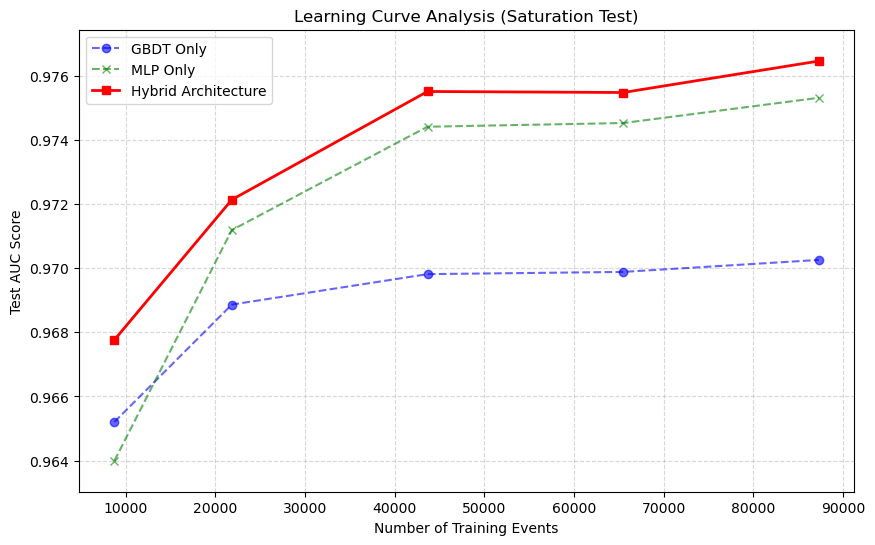

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input, Add, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

# --- 1. CONFIGURATION ---
FRACTIONS = [0.1, 0.25, 0.5, 0.75, 1.0]  # Learning Curve Steps
N_FOLDS = 5 
SEED = 42

# Force Determinism for fair comparison
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Storage
results = {
    'train_size': [],
    'gbdt': [],
    'mlp_standalone': [],
    'hybrid': []
}

# Define your exact FPGA Model Architecture (ResNet-MLP)
def create_fpga_model(input_dim):
    inputs = Input(shape=(input_dim,), name='input_1')
    x = Dense(256, name='fc1')(inputs); x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.1)(x)
    shortcut = Dense(128, name='shortcut')(x)
    x = Dense(128, name='fc2')(x); x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Add()([x, shortcut])
    x = Dense(64, name='fc3')(x); x = Activation('relu')(x)
    outputs = Dense(1, activation='sigmoid', name='output_node')(x)
    return Model(inputs, outputs)

print(f" STARTING LEARNING CURVE ANALYSIS (With Averaging at 100%)...")

# --- 2. MAIN LOOP ---
for frac in FRACTIONS:
    print(f"\nProcessing Data Fraction: {frac*100}%...")
    
    # A. Subsample Data (Stratified)
    if frac == 1.0:
        X_sub, y_sub = X_train, y_train
    else:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train, train_size=frac, stratify=y_train, random_state=SEED
        )
    
    results['train_size'].append(len(y_sub))
    
    # --- MODEL 1: GBDT BASELINE ---
    # Honest Stacking Prep (We need this for Hybrid anyway)
    kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    gbdt_train_scores_sub = np.zeros(len(X_sub))
    
    # Your specific XGB params
    params = {
        "n_estimators": 100, "learning_rate": 0.1, "max_depth": 4, 
        "eval_metric": "auc", "tree_method": "hist", "objective": "binary:logistic"
    }
    
    # 5-Fold CV for OOF Scores
    for train_idx, val_idx in kf.split(X_sub, y_sub):
        model_fold = xgb.XGBClassifier(**params)
        model_fold.fit(X_sub[train_idx], y_sub[train_idx])
        gbdt_train_scores_sub[val_idx] = model_fold.predict(X_sub[val_idx], output_margin=True)

    # Final GBDT fit on full subset
    gbdt_final = xgb.XGBClassifier(**params)
    gbdt_final.fit(X_sub, y_sub)
    gbdt_test_scores_sub = gbdt_final.predict(X_test, output_margin=True)
    
    # Score GBDT
    gbdt_auc = roc_auc_score(y_test, gbdt_test_scores_sub)
    results['gbdt'].append(gbdt_auc)

    # --- PREPROCESSING (Shared) ---
    # 1. Quantile Transform Physics Features
    qt_phys = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
    X_sub_phys = qt_phys.fit_transform(X_sub)
    X_test_phys_sub = qt_phys.transform(X_test)
    
    # 2. Quantile Transform GBDT Scores
    qt_gbdt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
    gbdt_tr_gauss = qt_gbdt.fit_transform(gbdt_train_scores_sub.reshape(-1, 1))
    gbdt_te_gauss = qt_gbdt.transform(gbdt_test_scores_sub.reshape(-1, 1))
    
    # 3. Stack for Hybrid
    X_train_hyb = np.hstack([X_sub_phys, gbdt_tr_gauss])
    X_test_hyb = np.hstack([X_test_phys_sub, gbdt_te_gauss])

    # --- MODEL 2 & 3: NEURAL NETWORKS ---
    
    # LOGIC SWITCH: 
    # If 100% Data -> Run 5 times and Average (To remove noise for Thesis Plot)
    # If <100% Data -> Run once (Speed)
    
    runs_to_average = 5 if frac == 1.0 else 1
    mlp_auc_runs = []
    hyb_auc_runs = []
    
    if runs_to_average > 1:
        print(f"   ⚡ Averaging {runs_to_average} runs to reduce variance...")
        
    for k in range(runs_to_average):
        # Unique seed for each run in the average loop
        iter_seed = SEED + k
        tf.random.set_seed(iter_seed)
        np.random.seed(iter_seed)
        
        # A. Standalone MLP Training
        tf.keras.backend.clear_session()
        model_mlp = create_fpga_model(X_sub_phys.shape[1])
        model_mlp.compile(Adam(0.001), 'binary_crossentropy', metrics=['accuracy'])
        model_mlp.fit(
            X_sub_phys, y_sub, epochs=30, batch_size=256, verbose=0,
            validation_data=(X_test_phys_sub, y_test),
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
        )
        mlp_probs = model_mlp.predict(X_test_phys_sub, verbose=0).flatten()
        mlp_auc_runs.append(roc_auc_score(y_test, mlp_probs))
        
        # B. Hybrid Training
        tf.keras.backend.clear_session()
        model_hyb = create_fpga_model(X_train_hyb.shape[1])
        model_hyb.compile(Adam(0.001), 'binary_crossentropy', metrics=['accuracy'])
        model_hyb.fit(
            X_train_hyb, y_sub, epochs=30, batch_size=256, verbose=0,
            validation_data=(X_test_hyb, y_test),
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
        )
        hyb_probs = model_hyb.predict(X_test_hyb, verbose=0).flatten()
        hyb_auc_runs.append(roc_auc_score(y_test, hyb_probs))

    # Calculate Final Average AUCs
    final_mlp_auc = np.mean(mlp_auc_runs)
    final_hyb_auc = np.mean(hyb_auc_runs)
    
    results['mlp_standalone'].append(final_mlp_auc)
    results['hybrid'].append(final_hyb_auc)
    
    print(f"   Events: {len(y_sub)} | GBDT: {gbdt_auc:.4f} | MLP: {final_mlp_auc:.4f} | Hybrid: {final_hyb_auc:.4f}")

# --- 3. PLOTTING (Modified to Save) ---
plt.figure(figsize=(10, 6))
plt.plot(results['train_size'], results['gbdt'], 'o--', label='GBDT Only', color='blue', alpha=0.6)
plt.plot(results['train_size'], results['mlp_standalone'], 'x--', label='MLP Only', color='green', alpha=0.6)
plt.plot(results['train_size'], results['hybrid'], 's-', label='Hybrid Architecture', color='red', linewidth=2)

plt.xlabel('Number of Training Events')
plt.ylabel('Test AUC Score')
plt.title(f'Learning Curve Analysis (Saturation Test)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Dynamic Zoom
min_y = min(min(results['gbdt']), min(results['mlp_standalone']), min(results['hybrid']))
max_y = max(results['hybrid'])
plt.ylim(min_y * 0.999, max_y * 1.001)

# --- SAVE COMMAND ---
plt.savefig('Fig_Learning_Curve.png', dpi=300, bbox_inches='tight') # <--- ADD THIS LINE
print(" Plot saved as Fig_Learning_Curve.png")

plt.show()

In [20]:
!pip install optuna optuna-integration

In [34]:
import os
import random
import numpy as np
import tensorflow as tf
import uproot
import awkward as ak
import pandas as pd
import xgboost as xgb
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input, Add, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==================================================================================
# 1. STRICT DETERMINISM & CONFIGURATION
# ==================================================================================
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f" DETERMINISM ENABLED.")

# UPDATE THIS PATH TO YOUR DATA FOLDER
DATA_DIR = r"C:\Users\tanma\Documents\Thesis_data"

# ==================================================================================
# 2. DATA LOADING & EXTRACTION
# ==================================================================================
def load_and_extract_v4(filename, label_value):
    filepath = os.path.join(DATA_DIR, filename)
    try:
        with uproot.open(filepath) as file:
            tree = file["events"]
            arrays = tree.arrays(["x", "y", "z", "edep", "t"], library="ak")
            if len(arrays) == 0: return None, None
            
            # Physics Features
            n_hits = ak.num(arrays["x"])
            r = np.sqrt(arrays["x"]**2 + arrays["y"]**2)
            r_mean = ak.mean(r, axis=1)
            r_std = ak.std(r, axis=1)
            r_span = ak.fill_none(ak.max(r, axis=1) - ak.min(r, axis=1), 0)
            z_span = ak.fill_none(ak.max(arrays["z"], axis=1) - ak.min(arrays["z"], axis=1), 0)
            z_std = ak.std(arrays["z"], axis=1)
            edep_sum = ak.sum(arrays["edep"], axis=1)
            edep_mean = ak.mean(arrays["edep"], axis=1)
            t_mean = ak.mean(arrays["t"], axis=1)
            t_std = ak.std(arrays["t"], axis=1)
            t_span = ak.fill_none(ak.max(arrays["t"], axis=1) - ak.min(arrays["t"], axis=1), 0)
            
            vol_density = n_hits / (z_span * r_span + 1e-6)
            lin_density = n_hits / (z_span + 1e-6)
            e_density = edep_sum / (n_hits + 1e-6)
            shape_ratio = z_span / (r_span + 1e-6)
            t_corr = t_span * edep_sum
            
            def to_np(arr): return ak.to_numpy(ak.fill_none(arr, 0)).astype(np.float32)

            features = np.stack([
                to_np(n_hits), to_np(r_mean), to_np(r_std), to_np(r_span),
                to_np(z_span), to_np(z_std), to_np(edep_sum), to_np(edep_mean),
                to_np(vol_density), to_np(lin_density), to_np(e_density), to_np(shape_ratio),
                to_np(t_mean), to_np(t_std), to_np(t_span), to_np(t_corr)
            ], axis=1)
            
            return np.nan_to_num(features, posinf=0, neginf=0), np.full(len(features), label_value)
    except Exception: return None, None

print("\n--- PROCESSING DATA ---")
X_sig, y_sig = load_and_extract_v4("VECTOR_SIGNAL_50k.root", 1)
X_dio, y_dio = load_and_extract_v4("VECTOR_DIO_50k.root", 0)
X_rmc, y_rmc = load_and_extract_v4("VECTOR_RMC_50k.root", 0)
X_cos, y_cos = load_and_extract_v4("VECTOR_COSMIC_75k.root", 0)

# --- AUGMENTATION (x50) ---
print(f"\n⚙️ AUGMENTING COSMICS (x50)...")
aug_cos_feats = []
aug_cos_labels = []
for i in range(50):
    noise = np.random.normal(1.0, 0.01, X_cos.shape) 
    aug_cos_feats.append(X_cos * noise)
    aug_cos_labels.append(y_cos)

X = np.concatenate([X_sig, X_dio, X_rmc, np.concatenate(aug_cos_feats)])
y = np.concatenate([y_sig, y_dio, y_rmc, np.concatenate(aug_cos_labels)])
print(f" FINAL DATASET: {len(X)} events")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)


# ==================================================================================
# PART A: OPTUNA STUDY 1 - GBDT (Optimizing AUC)
# ==================================================================================
print(f"\n{'='*60}")
print(f"🔬 OPTUNA STUDY 1: Gradient Boosted Decision Tree (GBDT)")
print(f"{'='*60}")

def objective_gbdt(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'booster': 'gbtree',
        'verbosity': 0,
        'n_jobs': 1,
        
        # FPGA-Friendly Search Space
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0)
    }

    # Manual CV Loop (Fixes NumPy 2.0 Crash)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_train[train_idx], y_train[train_idx],
            eval_set=[(X_train[val_idx], y_train[val_idx])],
            verbose=False
        )
        preds = model.predict_proba(X_train[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_train[val_idx], preds))
    
    return np.mean(aucs)

study_gbdt = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study_gbdt.optimize(objective_gbdt, n_trials=20)

print(f" GBDT STUDY COMPLETE.")
print(f"   Best Params: {study_gbdt.best_params}")
print(f"   Best AUC:    {study_gbdt.best_value:.5f}")


# ==================================================================================
# PART B: GENERATE STACKING FEATURES
# ==================================================================================
print("\n Generating Stacking Features for MLP...")

# Use FIXED params for consistency with FPGA bitstream
fixed_params = {
    'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4, 
    'eval_metric': 'auc', 'tree_method': 'hist'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gbdt_train_scores = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    model_fold = xgb.XGBClassifier(**fixed_params)
    model_fold.fit(X_train[train_idx], y_train[train_idx])
    gbdt_train_scores[val_idx] = model_fold.predict(X_train[val_idx], output_margin=True)

gbdt_final = xgb.XGBClassifier(**fixed_params)
gbdt_final.fit(X_train, y_train)
gbdt_test_scores = gbdt_final.predict(X_test, output_margin=True)
gbdt_probs = 1 / (1 + np.exp(-gbdt_test_scores))

# Preprocessing
qt_phys = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
X_train_phys = qt_phys.fit_transform(X_train)
X_test_phys = qt_phys.transform(X_test)


# ==================================================================================
# PART C: OPTUNA STUDY 2 - MLP ARCHITECTURE (Optimizing AUC)
# ==================================================================================
print(f"\n{'='*60}")
print(f"🔬 OPTUNA STUDY 2: ResNet-MLP Architecture")
print(f"{'='*60}")

def create_optuna_model(trial, input_dim):
    n_units_1 = trial.suggest_int('units_1', 64, 256, step=32)
    n_units_2 = trial.suggest_int('units_2', 32, 128, step=32)
    dropout_rate = trial.suggest_float('dropout', 0.0, 0.3)
    learning_rate = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    inputs = Input(shape=(input_dim,))
    x = Dense(n_units_1)(inputs); x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(dropout_rate)(x)
    
    # Residual Block
    shortcut = Dense(n_units_2)(x)
    x = Dense(n_units_2)(x); x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Add()([x, shortcut])
    
    x = Dense(int(n_units_2/2))(x); x = Activation('relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='auc')]) # Track AUC
    return model

def objective_mlp(trial):
    model = create_optuna_model(trial, X_train_phys.shape[1])
    history = model.fit(
        X_train_phys, y_train,
        epochs=10, batch_size=512, validation_split=0.2, verbose=0,
        callbacks=[TFKerasPruningCallback(trial, "val_auc")] # Prune on AUC
    )
    return history.history['val_auc'][-1]

study_mlp = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study_mlp.optimize(objective_mlp, n_trials=20)

print(f" MLP STUDY COMPLETE.")
print(f"   Best Params: {study_mlp.best_params}")
print(f"   Best Val AUC: {study_mlp.best_value:.5f}")


# ==================================================================================
# PART C.2: OPTUNA STUDY 3 - HYBRID ARCHITECTURE (Optimizing AUC)
# ==================================================================================
print(f"\n{'='*60}")
print(f" OPTUNA STUDY 3: Hybrid Architecture (Physics + GBDT)")
print(f"{'='*60}")

# Prepare Stacked Data
qt_gbdt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
gbdt_tr_gauss = qt_gbdt.fit_transform(gbdt_train_scores.reshape(-1, 1))
X_train_hyb_opt = np.hstack([X_train_phys, gbdt_tr_gauss])

def objective_hybrid(trial):
    model = create_optuna_model(trial, X_train_hyb_opt.shape[1])
    history = model.fit(
        X_train_hyb_opt, y_train,
        epochs=10, batch_size=512, validation_split=0.2, verbose=0,
        callbacks=[TFKerasPruningCallback(trial, "val_auc")]
    )
    return history.history['val_auc'][-1]

study_hybrid = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study_hybrid.optimize(objective_hybrid, n_trials=20)

print(f" HYBRID STUDY COMPLETE.")
print(f"   Best Params: {study_hybrid.best_params}")
print(f"   Best Val AUC: {study_hybrid.best_value:.5f}")


# ==================================================================================
# PART D: FINAL DEPLOYMENT TRAINING (Grand Ensemble)
# ==================================================================================
print(f"\n{'='*60}")
print(f" FINAL TRAINING (Fixed FPGA Configuration)")
print(f"{'='*60}")

# Use the FIXED architecture for Final Results (Safest for Thesis)
def create_fpga_model(input_dim):
    inputs = Input(shape=(input_dim,), name='input_1')
    x = Dense(256, name='fc1')(inputs); x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.1)(x)
    shortcut = Dense(128, name='shortcut')(x)
    x = Dense(128, name='fc2')(x); x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Add()([x, shortcut])
    x = Dense(64, name='fc3')(x); x = Activation('relu')(x)
    outputs = Dense(1, activation='sigmoid', name='output_node')(x)
    return Model(inputs, outputs)

# --- 1. TRAIN STANDALONE MLP ---
print("\n[Training Standalone MLP...]")
np.random.seed(SEED)
tf.random.set_seed(SEED)
model_mlp = create_fpga_model(X_train_phys.shape[1])
model_mlp.compile(Adam(0.001), 'binary_crossentropy', metrics=['accuracy']) # Metric here is just for display
model_mlp.fit(
    X_train_phys, y_train, epochs=40, batch_size=256, verbose=0,
    validation_data=(X_test_phys, y_test),
    callbacks=[ReduceLROnPlateau(patience=3), EarlyStopping(patience=7, restore_best_weights=True)]
)
mlp_probs = model_mlp.predict(X_test_phys).flatten()

# --- 2. TRAIN GRAND ENSEMBLE ---
print("\n[Training Grand Ensemble (5 Models)...]")
gbdt_te_gauss = qt_gbdt.transform(gbdt_test_scores.reshape(-1, 1))
X_train_hyb = np.hstack([X_train_phys, gbdt_tr_gauss])
X_test_hyb = np.hstack([X_test_phys, gbdt_te_gauss])

N_MODELS = 5
ensemble_preds = np.zeros(len(X_test))

for i in range(N_MODELS):
    iter_seed = SEED + i 
    np.random.seed(iter_seed)
    tf.random.set_seed(iter_seed)
    model = create_fpga_model(X_train_hyb.shape[1])
    model.compile(Adam(0.001), 'binary_crossentropy', metrics=['accuracy'])
    model.fit(
        X_train_hyb, y_train, epochs=40, batch_size=256, verbose=0,
        validation_data=(X_test_hyb, y_test),
        callbacks=[ReduceLROnPlateau(patience=3), EarlyStopping(patience=7, restore_best_weights=True)]
    )
    ensemble_preds += model.predict(X_test_hyb, verbose=0).flatten()

final_ensemble_probs = ensemble_preds / N_MODELS

# --- 3. FINAL RESULTS ---
def calc_stats(probs, y):
    auc = roc_auc_score(y, probs)
    fpr, tpr, _ = roc_curve(y, probs)
    with np.errstate(divide='ignore'): rejection = 1.0 / fpr
    idx = np.abs(tpr - 0.90).argmin()
    return auc, rejection[idx]

auc_g, rej_g = calc_stats(gbdt_probs, y_test)
auc_m, rej_m = calc_stats(mlp_probs, y_test)
auc_h, rej_h = calc_stats(final_ensemble_probs, y_test)

print(f"{'-'*60}")
print(f"{'MODEL':<20} | {'AUC':<10} | {'REJECTION (@90% Eff)':<20}")
print(f"{'-'*60}")
print(f"{'GBDT':<20} | {auc_g:.5f}    | {rej_g:.1f}")
print(f"{'MLP':<20} | {auc_m:.5f}    | {rej_m:.1f}")
print(f"{'HYBRID':<20} | {auc_h:.5f}    | {rej_h:.1f}")
print(f"{'-'*60}")

 DETERMINISM ENABLED.

--- PROCESSING DATA ---


[I 2026-01-23 01:51:58,856] A new study created in memory with name: no-name-d1892e58-bf39-4122-bc92-7e3acc494501



 AUGMENTING COSMICS (x50)...
 FINAL DATASET: 109123 events

🔬 OPTUNA STUDY 1: Gradient Boosted Decision Tree (GBDT)


[I 2026-01-23 01:52:03,943] Trial 0 finished with value: 0.9625349254478391 and parameters: {'max_depth': 6, 'learning_rate': 0.01503658386182946, 'n_estimators': 78, 'subsample': 0.6510451488899888, 'colsample_bytree': 0.851354815156475, 'gamma': 0.4814155466813458}. Best is trial 0 with value: 0.9625349254478391.
[I 2026-01-23 01:52:11,277] Trial 1 finished with value: 0.9617174611131354 and parameters: {'max_depth': 3, 'learning_rate': 0.05649952874927964, 'n_estimators': 165, 'subsample': 0.789046109824066, 'colsample_bytree': 0.9407694173740585, 'gamma': 2.172577339638391}. Best is trial 0 with value: 0.9625349254478391.
[I 2026-01-23 01:52:15,788] Trial 2 finished with value: 0.9600594319510742 and parameters: {'max_depth': 3, 'learning_rate': 0.08378048139313006, 'n_estimators': 93, 'subsample': 0.8154538375906398, 'colsample_bytree': 0.9540483630915254, 'gamma': 0.4128662373919295}. Best is trial 0 with value: 0.9625349254478391.
[I 2026-01-23 01:52:20,973] Trial 3 finished wit

 GBDT STUDY COMPLETE.
   Best Params: {'max_depth': 6, 'learning_rate': 0.15960199598789362, 'n_estimators': 147, 'subsample': 0.8428166748251039, 'colsample_bytree': 0.86619848713351, 'gamma': 1.3109007049304306}
   Best AUC:    0.97522

 Generating Stacking Features for MLP...


...


🔬 OPTUNA STUDY 2: ResNet-MLP Architecture


[I 2026-01-23 01:54:19,813] Trial 0 finished with value: 0.970556914806366 and parameters: {'units_1': 224, 'units_2': 128, 'dropout': 0.15213746885998516, 'lr': 0.0009612707925273808}. Best is trial 0 with value: 0.970556914806366.
[I 2026-01-23 01:54:31,834] Trial 1 finished with value: 0.9642409086227417 and parameters: {'units_1': 128, 'units_2': 128, 'dropout': 0.09424854741047511, 'lr': 0.00015535267374175654}. Best is trial 0 with value: 0.970556914806366.
[I 2026-01-23 01:54:43,841] Trial 2 finished with value: 0.9702680706977844 and parameters: {'units_1': 192, 'units_2': 96, 'dropout': 0.25588793512512265, 'lr': 0.004329307007342375}. Best is trial 0 with value: 0.970556914806366.
[I 2026-01-23 01:54:51,683] Trial 3 finished with value: 0.9730623364448547 and parameters: {'units_1': 128, 'units_2': 64, 'dropout': 0.0060525811420699795, 'lr': 0.001639306550192553}. Best is trial 3 with value: 0.9730623364448547.
[I 2026-01-23 01:55:01,633] Trial 4 finished with value: 0.960686

 MLP STUDY COMPLETE.
   Best Params: {'units_1': 128, 'units_2': 64, 'dropout': 0.0060525811420699795, 'lr': 0.001639306550192553}
   Best Val AUC: 0.97306

 OPTUNA STUDY 3: Hybrid Architecture (Physics + GBDT)


[I 2026-01-23 01:57:10,444] Trial 0 finished with value: 0.9719232320785522 and parameters: {'units_1': 160, 'units_2': 128, 'dropout': 0.27515520684821376, 'lr': 0.00316239686484714}. Best is trial 0 with value: 0.9719232320785522.
[I 2026-01-23 01:57:23,390] Trial 1 finished with value: 0.9729435443878174 and parameters: {'units_1': 96, 'units_2': 96, 'dropout': 0.015904124940477635, 'lr': 0.0006411327638624905}. Best is trial 1 with value: 0.9729435443878174.
[I 2026-01-23 01:57:31,313] Trial 2 finished with value: 0.9707433581352234 and parameters: {'units_1': 128, 'units_2': 64, 'dropout': 0.05815452588952391, 'lr': 0.00012415408468672458}. Best is trial 1 with value: 0.9729435443878174.
[I 2026-01-23 01:57:41,010] Trial 3 finished with value: 0.9716295599937439 and parameters: {'units_1': 96, 'units_2': 64, 'dropout': 0.21729104634290633, 'lr': 0.00045368722041204987}. Best is trial 1 with value: 0.9729435443878174.
[I 2026-01-23 01:57:49,975] Trial 4 finished with value: 0.97141

 HYBRID STUDY COMPLETE.
   Best Params: {'units_1': 96, 'units_2': 128, 'dropout': 0.01008200288401323, 'lr': 0.003247888855452806}
   Best Val AUC: 0.97382

 FINAL TRAINING (Fixed FPGA Configuration)

[Training Standalone MLP...]
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step

[Training Grand Ensemble (5 Models)...]
------------------------------------------------------------
MODEL                | AUC        | REJECTION (@90% Eff)
------------------------------------------------------------
GBDT                 | 0.97026    | 14.2
MLP                  | 0.97807    | 20.1
HYBRID               | 0.97814    | 20.2
------------------------------------------------------------


In [ ]:
# --- HYPOTHETICAL 200 kHz COMPARISON ---
print(f"\n{'='*60}")
print(f"⚔️ 200 kHz STRESS TEST (Comparing vs Other Research)")
print(f"{'='*60}")

target_output_rate = 13.0 # kHz
hypothetical_input = 200.0 # kHz
required_rejection = hypothetical_input / target_output_rate # ~15.38

# Calculate Efficiency at exactly Rejection = 15.38
# We use interpolation on the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, final_ensemble_probs)
rejection_curve = 1.0 / (fpr + 1e-9) # Avoid division by zero

# Find TPR (Signal Eff) where Rejection matches required_rejection
# Note: Rejection is decreasing as TPR increases, so we flip for interp
eff_at_200k = np.interp(required_rejection, rejection_curve[::-1], tpr[::-1])

print(f"Scenario: Input {hypothetical_input} kHz -> Output {target_output_rate} kHz")
print(f"Required Rejection Factor: {required_rejection:.2f}")
print(f"------------------------------------------------------------")
print(f"Other Research Signal Eff:  66.00%")
print(f"YOUR Model Signal Eff:      {eff_at_200k*100:.2f}%")
print(f"------------------------------------------------------------")
print(f"Performance Gain:           +{((eff_at_200k - 0.66)*100):.2f}% (Absolute)")

In [ ]:
import numpy as np

# 1. Get the scores of ONLY the signal events (Label == 1)
signal_scores = df[df['label'] == 1]['prediction_score']

# 2. Calculate the 10th percentile
threshold_at_90 = np.percentile(signal_scores, 10)

print(f"To achieve 90% efficiency, the cut score is: {threshold_at_90}")